In [7]:
import requests
import os
import ahttp
import pandas as pd
from astropy.io import ascii
import numpy as np
from astropy.table import Table
import sys


def get_by_position(ra, dec, radius=2.5):
    ALLWISE_cat = 'allwise_p3as_mep'                                                                                                                                                        
    NEOWISE_cat = 'neowiser_p1bs_psd'
    query_url = 'http://irsa.ipac.caltech.edu/cgi-bin/Gator/nph-query'
    payload = {
        'catalog': ALLWISE_cat,
        'spatial': 'cone',
        'objstr': ' '.join([str(ra), str(dec)]),
        'radius': str(radius),
        'radunits': 'arcsec',
        'outfmt': '1'
    }
    r = requests.get(query_url, params=payload)
    allwise = ascii.read(r.text)
    payload = {
        'catalog': NEOWISE_cat,
        'spatial': 'cone',
        'objstr': ' '.join([str(ra), str(dec)]),
        'radius': str(radius),
        'radunits': 'arcsec',
        'outfmt': '1',
        'selcols': 'ra,dec,sigra,sigdec,sigradec,glon,glat,elon,elat,w1mpro,w1sigmpro,w1snr,w1rchi2,w2mpro,w2sigmpro,w2snr,w2rchi2,rchi2,nb,na,w1sat,w2sat,satnum,cc_flags,det_bit,ph_qual,sso_flg,qual_frame,qi_fact,saa_sep,moon_masked,w1frtr,w2frtr,mjd,allwise_cntr,r_allwise,pa_allwise,n_allwise,w1mpro_allwise,w1sigmpro_allwise,w2mpro_allwise,w2sigmpro_allwise,w3mpro_allwise,w3sigmpro_allwise,w4mpro_allwise,w4sigmpro_allwise'
    }
    
    r = requests.get(query_url, params=payload)

    neowise = ascii.read(r.text, guess=False, format='ipac')

    return allwise, neowise

    
def download_single_data(name, ra, dec, root_path='./ipac/', radius=2.5):
    # ra, dec: in degree
    # name, ra, dec = row['Name'], row['RAJ2000'], row['DEJ2000']
    # name = 'J' + ra + dec
    if root_path[-1] != '/':
        root_path += '/'
    if os.path.isfile(root_path + name +str(ra)[0:10]+'_'+str(dec)[0:10]+ '_allwise.ipac') and os.path.isfile(root_path + name +str(ra)[0:10]+'_'+str(dec)[0:10]+ '_neowise.ipac'):
        pass
    else:
        allwise, neowise = get_by_position(ra, dec, radius=radius)
        allwise.write(root_path + name +str(ra)[0:10]+'_'+str(dec)[0:10]+ '_allwise.ipac', format='ascii.ipac', overwrite=True)
        neowise.write(root_path + name + str(ra)[0:10]+'_'+str(dec)[0:10]+'_neowise.ipac', format='ascii.ipac', overwrite=True)



In [13]:
from astropy import units as u
from astropy.coordinates import SkyCoord
c = SkyCoord('02h12m18.62s', '00d44m56.50s', frame='icrs')
c

<SkyCoord (ICRS): (ra, dec) in deg
    (33.07758333, 0.74902778)>

In [8]:
def get_data_arrays(table, t, mag, magerr):
    """Get the time series from a potentially masked astropy table"""
    if table.masked:
        full_mask = table[t].mask | table[mag].mask | table[magerr].mask
        t = table[t].data
        mag = table[mag].data
        magerr = table[magerr].data

        t.mask = full_mask
        mag.mask = full_mask
        magerr.mask = full_mask

        return t.compressed(), mag.compressed(), magerr.compressed()

    else:
        return table[t].data, table[mag].data, table[magerr].data

def make_full_lightcurve(allwise, neowise, band):
    """band = 'w1', 'w2', 'w3', or 'w4' """
    """Get a combined AllWISE and NEOWISE lightcurve from their Astropy tables"""

    if band not in ['w1', 'w2', 'w3', 'w4']:
        raise ValueError('band can only be w1, w2, w3, or w4')

    t, m, e = get_data_arrays(allwise, 'mjd', band + 'mpro_ep', band + 'sigmpro_ep')
    if band in ['w1', 'w2']:
        t_n, m_n, e_n = get_data_arrays(neowise, 'mjd', band + 'mpro', band + 'sigmpro')
        t, m, e = np.concatenate((t, t_n)), np.concatenate((m, m_n)), np.concatenate((e, e_n))

    t_index = t.argsort()
    t, m, e = map(lambda e: e[t_index], [t, m, e])
    return t, m, e

def cntr_to_source_id(cntr):
    cntr = str(cntr)

    # fill leanding 0s
    if len(cntr) < 19:
        num_leading_zeros = 19 - len(cntr)
        cntr = '0' * num_leading_zeros + cntr

    pm = 'p'
    if cntr[4] == '0':
        pm = 'm'

    t = chr(96 + int(cntr[8:10]))

    # return '%04d%s%03d_%sc%02d-%06d' %(cntr[0:4], pm, cntr[5:8], t, cntr[11:13], cntr[13:19])
    return '%s%s%s_%cc%s-%s' % (cntr[0:4], pm, cntr[5:8], t, cntr[11:13], cntr[13:19])

def only_good_data_v1(allwise, neowise):
    """
    Select good-quality data. The criteria include:
    - matching the all-wise ID

    To be done:
    - deal with multiple cntr
    """

    cntr_list = []
    for data in neowise:
        # print data['allwise_cntr']
        if data['allwise_cntr'] not in cntr_list and data['allwise_cntr'] > 10.:
            cntr_list.append(data['allwise_cntr'])

    if len(cntr_list) >= 2:
        print('multiple cntr:')
        print(cntr_list)
        return 0, 0

    if len(cntr_list) == 0:
        print('no cntr')
        return 0, 0

    cntr = cntr_list[0]

    source_id = cntr_to_source_id(cntr)

    allwise = allwise[
        (allwise['source_id_mf'] == source_id) *
        (allwise['saa_sep'] > 0.) *
        (allwise['moon_masked'] == '0000') *
        (allwise['qi_fact'] > 0.9)
        ]

    # old version
    # neowise = neowise[
    #    (neowise['qual_frame'] > 0.)
    # ]

    # new version
    neowise = neowise[
        (neowise['qual_frame'] > 0.) *
        (neowise['qi_fact'] > 0.9) *
        (neowise['saa_sep'] > 0) *
        (neowise['moon_masked'] == '00')
        ]

    return allwise, neowise

def make_full_lightcurve_multibands(allwise, neowise, bands=['w1', 'w2']):
    t, m, e = make_full_lightcurve(allwise, neowise, bands[0])
    filts = [bands[0] for i in range(len(t))]
    for band in bands[1:]:
        t_tmp, m_tmp, e_tmp = make_full_lightcurve(allwise, neowise, band)
        t = np.concatenate((t, t_tmp))
        m = np.concatenate((m, m_tmp))
        e = np.concatenate((e, e_tmp))
        filts += [band for i in range(len(t_tmp))]
    return t, m, e, np.array(filts)


In [3]:
import matplotlib.pyplot as plt
from util import bin_the_light_curve

def neowise_viewer_show(path, ra, dec):
    ra_str = str(ra)[0:10]
    dec_str = str(dec)[0:10]
    allwise = ascii.read(path + '%s_%s_allwise.ipac'%(ra_str,dec_str), format='ipac')
    neowise = ascii.read(path + '%s_%s_neowise.ipac'%(ra_str,dec_str), format='ipac')
    # allwise, neowise = only_good_data_v1(allwise, neowise)
    t, mag, mag_err, filts = make_full_lightcurve_multibands(allwise, neowise)
    t_w1 = t[filts == 'w1']
    t_w2 = t[filts == 'w2']
    mag_w1 = mag[filts == 'w1']
    mag_w2 = mag[filts == 'w2']
    mag_err_w1 = mag_err[filts == 'w1']
    mag_err_w2 = mag_err[filts == 'w2']

    t1,m1,e1 = bin_the_light_curve(t_w1,mag_w1,mag_err_w1)
    plt.errorbar(t1,m1,e1, fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)
    plt.title('w1')
    
    t2,m2,e2 = bin_the_light_curve(t_w2,mag_w2,mag_err_w2)
    plt.errorbar(t2,m2,e2, fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)
    plt.title('w2')
    # plt.ylim(12,15)
    plt.gca().invert_yaxis()
    plt.show()


In [4]:
from astropy.coordinates import SkyCoord
from astropy import units as u

def ra_dec_to_degrees_simple(ra_str, dec_str):
    """
    简洁版本的坐标转换
    """
    coord = SkyCoord(ra=ra_str, dec=dec_str, unit=(u.hourangle, u.deg))
    return coord.ra.deg, coord.dec.deg

ra = '00 44 10.72'
dec = '+41 54 22.1'

ra,dec = ra_dec_to_degrees_simple(ra,dec)
print(ra,dec)

download_single_data(name='IR_extreme_luminious_', ra=ra, dec=dec,
            root_path='./ipac/', radius=5)

11.044666666666664 41.90613888888889


In [6]:
ra,dec = 73.92716, -65.83936

In [7]:

download_single_data(name='IR_extreme_luminious_', ra=ra, dec=dec,
            root_path='./ipac/', radius=5)

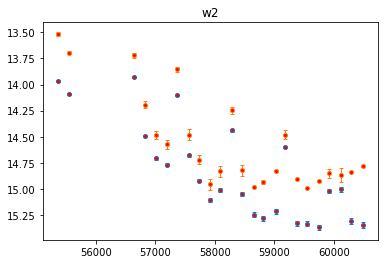

In [9]:
neowise_viewer_show('./ipac/IR_extreme_luminious_', ra, dec)

In [77]:
'change look agn'
'https://simbad.u-strasbg.fr/simbad/sim-ref?querymethod=bib&simbo=on&submit=submit+bibcode&bibcode=2025ApJS..278...28G'
''' 
31.56662345047 -0.29145048158
33.6398352978 -0.76671717926
128.91165878728998 -4.0883058622999995
166.2298745833333 1.3157355555555557
177.76573833227 53.02797046619
181.19964417608998 17.049124344430002
228.44070254053 31.19027284134
233.29176554151996 27.488956805500003
235.98998587499997 10.10377086111111
247.12157041493995 43.4968152435
'''

'EXor-type outbursting young stellar objects VY Tau'
'https://scixplorer.org/abs/2016ApJ...816L..29L/abstract'
'69.82258085984 22.798152372870003'

'EX Lupi-type:'
'https://scixplorer.org/abs/2014ApJ...785L..35H/abstract'
'77.54616666666666 -3.4739722222222222'
'https://scixplorer.org/abs/2025ApJ...987...37N/abstract'
'286.1111912167887 4.399277632273612'


'FU Ori–type:'
'https://scixplorer.org/abs/2018ApJ...869..146H/abstract'
'292.77328412146994 18.4645095072'
'https://scixplorer.org/abs/2024MNRAS.52711651A/abstract'
'326.77504166666665 47.660944444444446'
'https://scixplorer.org/abs/2017A&A...607A..39F/abstract'
'314.7238897280399 44.2578857577'
'305.95006607208995 42.20716146641'
'312.85931966189 44.089963709580005'
'314.57095015307993 43.89537268921'
'343.38857456874996 62.539897052069996'

'UX Ori Type '
'https://scixplorer.org/abs/2020Ap.....63..482P/abstract'
'249.77677942262997 9.79869776414'
'https://scixplorer.org/abs/2008Ap.....51....1G/abstract'
'83.99361094339 24.74835873627'
'86.7657260228 21.00966287769'

'Luminous Blue Variables (LBVs):'
'https://iopscience.iop.org/article/10.3847/2041-8213/ab430b/pdf'
'9.336000025919999 40.27714082946'
'https://scixplorer.org/abs/2025AJ....169..128S/abstract'
'167.16693092004 -60.71436703335'

'Wolf-Rayet:'
'https://scixplorer.org/abs/1981SSRv...28..227V/abstract'
'154.82667516446998 -59.16079151598'
'164.97049340866 -59.87872198241'
'244.0574730438629 -51.61160725674861'

'Red Supergiants:'
'https://scixplorer.org/abs/2022RNAAS...6..204L/abstract'
'42.65788739325999 56.98341323747'
'https://scixplorer.org/abs/2006MNRAS.372.1721K/abstract'
'94.69728093536999 -17.040830829780003'

'Classical Nova:'
'https://scixplorer.org/abs/2025ApJ...983..148S/abstract'
'200.20725 -62.630694444444444'
'https://scixplorer.org/abs/2025ApJ...980..142H/abstract'
'71.97583941114 -10.17860062984'
'https://scixplorer.org/abs/2025ApJ...984..136H/abstract'
'70.83903928374 47.357186049010004'
'https://scixplorer.org/abs/2024ApJ...965...49H/abstract'
'305.87786031333746 20.76771594868611'

'Symbiotic Stars:'
'https://scixplorer.org/abs/2022MNRAS.510.2707I/abstract'
'100.729739348 55.47423173053'
'https://scixplorer.org/abs/2016MNRAS.462.4435T/abstract'
'327.75822470723 12.62559109426'
'https://scixplorer.org/abs/2024SerAJ.208...41Z/abstract'
'298.9264096433 32.09695730152'
'https://scixplorer.org/abs/2023MNRAS.526.6381S/abstract'
'275.70604458536326 -24.141455328919164'
'https://scixplorer.org/abs/2022MNRAS.510.1404M/abstract'
'196.55388075195998 -53.38124999465'

'Microquasars(X-ray Binaries):'
'https://scixplorer.org/abs/2025ApJ...979L..40M/abstract'
'288.79814899999997 10.945807'
'https://scixplorer.org/abs/2024Sci...383..402H/abstract'
'287.95651987394996 4.9827297576800005'
'https://scixplorer.org/abs/2016Natur.531..341S/abstract'
'306.0159393578233 33.867211718259725'
'https://scixplorer.org/abs/2023MNRAS.524L..89K/abstract'
'308.1074166666666 40.957750000000004'

'TDE:'
'https://scixplorer.org/abs/2022MNRAS.511.5328G/abstract'
'123.32057083333332 22.64827777777778'
'https://scixplorer.org/abs/2020MNRAS.499..482N/abstract'
'71.65783333333331 -10.226366666666667'
'https://scixplorer.org/abs/2021MNRAS.504..792C/abstract'
'314.26237499999996 14.204405555555555'
'https://scixplorer.org/abs/2022MNRAS.517...76O/abstract'
'245.14524999999998 24.12377777777778'
'https://scixplorer.org/abs/2019ApJ...885..110Y/abstract'
'254.36171519395998 23.75781338366' #(unusual)

'supernpvae:'
'https://scixplorer.org/abs/2021ApJ...917...63A/abstract'
'24.2067875 15.77946388888889'
'https://scixplorer.org/abs/2025ApJ...980L..33M/abstract'
'232.96470833333333 37.4124'
'https://scixplorer.org/abs/2023ApJ...945L...2D/abstract'
'64.9725 -54.94808055555555'
'https://scixplorer.org/abs/2018MNRAS.481.2536K/abstract'
'308.68432499999994 60.19333333333333'

'Post-AGB Star(Proto-Planetary Nebulae):'
'https://scixplorer.org/abs/2024JApA...45...27I/abstract'
'265.25018545133 -16.30345724815'
'https://scixplorer.org/abs/2019JAVSO..47...83L/abstract'
'280.08303767866994 -22.908141168809998'
'https://scixplorer.org/abs/2018AAS...23140806P/abstract'
'70.72343418025 36.11483358395'
'https://scixplorer.org/abs/2018AJ....156..300H/abstract'
'266.23112273477994 50.044300784259995'
'272.87775897109 27.087677156279998'


'V838 Mon: red novae remnant'
'https://scixplorer.org/abs/2021A&A...655A.100M/abstract'
'https://scixplorer.org/abs/2021A&A...655A..32K/abstract'
'106.02009228957999 -3.84740247067'

'305.95006607208995 42.20716146641'

In [1]:
# -*- coding: utf-8 -*-
"""
Light Curve Feature Extraction for Multi-modal AI Supplement
Input: MJD and magnitude for two bands, with 7-day alignment tolerance
Output: JSON file with feature names, values, and explanations
"""

import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import find_peaks
from astropy.timeseries import LombScargle
import json
from datetime import datetime
import os

def align_light_curves(mjd1, mag1, err1, mjd2, mag2, err2, max_time_diff=7.0):
    """
    Align two light curves considering observations within 7 days as simultaneous
    """
    # Convert to numpy arrays and remove NaN values
    mjd1, mag1, err1 = np.array(mjd1), np.array(mag1), np.array(err1)
    mjd2, mag2, err2 = np.array(mjd2), np.array(mag2), np.array(err2)
    
    mask1 = ~(np.isnan(mjd1) | np.isnan(mag1))
    mask2 = ~(np.isnan(mjd2) | np.isnan(mag2))
    
    mjd1, mag1, err1 = mjd1[mask1], mag1[mask1], err1[mask1]
    mjd2, mag2, err2 = mjd2[mask2], mag2[mask2], err2[mask2]
    
    # Find common time points within tolerance
    common_times = []
    mag1_aligned = []
    mag2_aligned = []
    err1_aligned = []
    err2_aligned = []
    
    # For each observation in band1, find closest band2 observation within tolerance
    for i, t1 in enumerate(mjd1):
        time_diffs = np.abs(mjd2 - t1)
        min_idx = np.argmin(time_diffs)
        min_diff = time_diffs[min_idx]
        
        if min_diff <= max_time_diff:
            # Use average time of the two observations
            avg_time = (t1 + mjd2[min_idx]) / 2
            common_times.append(avg_time)
            mag1_aligned.append(mag1[i])
            mag2_aligned.append(mag2[min_idx])
            err1_aligned.append(err1[i])
            err2_aligned.append(err2[min_idx])
    
    # Also check for band2 observations that might not have matched with band1
    for j, t2 in enumerate(mjd2):
        time_diffs = np.abs(mjd1 - t2)
        min_idx = np.argmin(time_diffs)
        min_diff = time_diffs[min_idx]
        
        if min_diff <= max_time_diff:
            avg_time = (t2 + mjd1[min_idx]) / 2
            # Check if this time point already exists (with some tolerance)
            existing_times = np.array(common_times) if common_times else np.array([])
            if len(existing_times) == 0 or np.min(np.abs(existing_times - avg_time)) > 0.1:
                common_times.append(avg_time)
                mag1_aligned.append(mag1[min_idx])
                mag2_aligned.append(mag2[j])
                err1_aligned.append(err1[min_idx])
                err2_aligned.append(err2[j])
    
    # Sort by time
    if common_times:
        sort_idx = np.argsort(common_times)
        common_times = np.array(common_times)[sort_idx]
        mag1_aligned = np.array(mag1_aligned)[sort_idx]
        mag2_aligned = np.array(mag2_aligned)[sort_idx]
        err1_aligned = np.array(err1_aligned)[sort_idx]
        err2_aligned = np.array(err2_aligned)[sort_idx]
    
    return {
        'time': common_times,
        'mag1': mag1_aligned,
        'mag2': mag2_aligned,
        'err1': err1_aligned,
        'err2': err2_aligned
    }

def calculate_sampling_periods(times):
    """
    Calculate dominant sampling periods to identify potential aliasing issues
    """
    if len(times) < 4:
        return {"error": "Insufficient data for sampling analysis"}
    
    # Calculate time differences
    time_diffs = np.diff(times)
    
    # Calculate histogram of time differences to find dominant sampling intervals
    hist, bin_edges = np.histogram(time_diffs, bins=min(10, len(time_diffs)))
    dominant_bin_idx = np.argmax(hist)
    dominant_interval = (bin_edges[dominant_bin_idx] + bin_edges[dominant_bin_idx + 1]) / 2
    
    # Calculate median and mode of sampling intervals
    median_interval = np.median(time_diffs)
    
    # Try to find mode (most common interval)
    unique, counts = np.unique(np.round(time_diffs, 1), return_counts=True)
    mode_interval = unique[np.argmax(counts)] if len(unique) > 0 else median_interval
    
    return {
        "median_sampling_interval": float(median_interval),
        "mode_sampling_interval": float(mode_interval),
        "dominant_histogram_interval": float(dominant_interval),
        "sampling_interval_std": float(np.std(time_diffs)),
        "sampling_regularity": float(1 - (np.std(time_diffs) / median_interval)) if median_interval > 0 else 0
    }

def calculate_essential_features(mjd1, mag1, err1, mjd2, mag2, err2, output_filename):
    """
    Calculate essential light curve features for AI model supplementation
    """
    
    # Align the light curves
    aligned_data = align_light_curves(mjd1, mag1, err1, mjd2, mag2, err2)
    
    # Extract aligned data
    t_aligned = aligned_data['time']
    m1_aligned = aligned_data['mag1']
    m2_aligned = aligned_data['mag2']
    e1_aligned = aligned_data['err1']
    e2_aligned = aligned_data['err2']
    
    # Use original data for single-band features
    t1, m1, e1 = np.array(mjd1), np.array(mag1), np.array(err1)
    t2, m2, e2 = np.array(mjd2), np.array(mag2), np.array(err2)
    
    # Remove NaN values from original data
    mask1 = ~(np.isnan(t1) | np.isnan(m1))
    mask2 = ~(np.isnan(t2) | np.isnan(m2))
    t1, m1, e1 = t1[mask1], m1[mask1], e1[mask1]
    t2, m2, e2 = t2[mask2], m2[mask2], e2[mask2]
    
    features = {
        'metadata': {
            'generated_at': datetime.now().isoformat(),
            'input_filename': output_filename,
            'data_points_band1': len(t1),
            'data_points_band2': len(t2),
            'aligned_data_points': len(t_aligned),
            'description': 'Essential light curve features for multi-modal AI supplementation'
        },
        'features': []
    }
    
    # Helper function to add features with consistent format
    def add_feature(category, name, value, explanation):
        features['features'].append({
            'category': category,
            'name': name,
            'value': value,
            'explanation': explanation
        })
    
    # ===========================================
    # 1. Basic Variability Features
    # ===========================================
    if len(m1) > 0:
        add_feature('variability', 'band1_peak_to_peak_amplitude', 
                   float(np.nanmax(m1) - np.nanmin(m1)),
                   'Total brightness variation range in band 1. Caution: Sparse sampling may underestimate true amplitude.')
        
        add_feature('variability', 'band1_rms_variability', 
                   float(np.sqrt(np.nanmean((m1 - np.nanmean(m1))**2))),
                   'Root mean square variability in band 1. More reliable than peak-to-peak for sparse data.')
        
        add_feature('variability', 'band1_median_absolute_deviation', 
                   float(np.nanmedian(np.abs(m1 - np.nanmedian(m1)))),
                   'Robust measure of variability in band 1. Less sensitive to outliers than RMS.')
        
        if len(m1) > 2:
            # Add sample size warning for higher moments
            skew_exp = f'Asymmetry of brightness distribution in band 1 (positive = right-skewed). '
            skew_exp += f'Estimated from {len(m1)} points. Caution: Higher moments require larger samples for reliability.'
            add_feature('variability', 'band1_skewness', 
                       float(stats.skew(m1)),
                       skew_exp)
            
            kurt_exp = f'Tailedness of brightness distribution in band 1 (positive = heavy tails). '
            kurt_exp += f'Estimated from {len(m1)} points. Caution: Kurtosis estimates are noisy with small samples.'
            add_feature('variability', 'band1_kurtosis', 
                       float(stats.kurtosis(m1)),
                       kurt_exp)
    
    if len(m2) > 0:
        add_feature('variability', 'band2_peak_to_peak_amplitude', 
                   float(np.nanmax(m2) - np.nanmin(m2)),
                   'Total brightness variation range in band 2. Caution: Sparse sampling may underestimate true amplitude.')
        
        add_feature('variability', 'band2_rms_variability', 
                   float(np.sqrt(np.nanmean((m2 - np.nanmean(m2))**2))),
                   'Root mean square variability in band 2. More reliable than peak-to-peak for sparse data.')
    
    # ===========================================
    # 2. Temporal Structure Features
    # ===========================================
    if len(t1) > 1:
        dt1 = np.diff(t1)
        sampling_info = calculate_sampling_periods(t1)
        
        add_feature('temporal', 'band1_median_sampling_interval', 
                   float(np.nanmedian(dt1)),
                   'Typical time between observations in band 1 (days). Half-year sampling common in this dataset.')
        
        add_feature('temporal', 'band1_max_gap', 
                   float(np.nanmax(dt1)),
                   'Largest gap between observations in band 1 (days). Large gaps may miss important variability events.')
        
        add_feature('temporal', 'band1_total_timespan', 
                   float(np.nanmax(t1) - np.nanmin(t1)),
                   'Total duration of observations in band 1 (days). Longer baselines improve period detection.')
        
        if 'median_sampling_interval' in sampling_info:
            add_feature('temporal', 'band1_sampling_regularity', 
                       sampling_info['sampling_regularity'],
                       'Measure of how regular sampling is (1 = perfectly regular). Regular sampling can cause aliasing in period analysis.')
    
    if len(t2) > 1:
        dt2 = np.diff(t2)
        add_feature('temporal', 'band2_median_sampling_interval', 
                   float(np.nanmedian(dt2)),
                   'Typical time between observations in band 2 (days). Half-year sampling common in this dataset.')
    
    # ===========================================
    # 3. Color and Inter-band Features
    # ===========================================
    if len(t_aligned) > 2:
        color = m1_aligned - m2_aligned
        
        color_exp = f'Average color (band1 - band2) across {len(t_aligned)} aligned observations. '
        color_exp += 'Large variations may indicate different physical processes in different bands.'
        add_feature('color', 'mean_color', 
                   float(np.nanmean(color)),
                   color_exp)
        
        add_feature('color', 'color_variability', 
                   float(np.nanstd(color)),
                   'Standard deviation of color variations. Stable colors suggest similar physical origins across bands.')
        
        add_feature('color', 'color_amplitude', 
                   float(np.nanmax(color) - np.nanmin(color)),
                   'Total range of color variations. Large amplitudes may indicate spectral changes.')
        
        # Correlation between bands
        if len(m1_aligned) > 1:
            corr_coef = np.corrcoef(m1_aligned, m2_aligned)[0, 1]
            corr_exp = f'Pearson correlation between bands based on {len(t_aligned)} aligned points. '
            corr_exp += 'High correlation suggests coordinated variability across bands.'
            add_feature('color', 'band_correlation', 
                       float(corr_coef),
                       corr_exp)
    
    # ===========================================
    # 4. Trend Features
    # ===========================================
    if len(t1) > 2 and len(m1) > 2:
        # Linear trend
        valid_mask = ~(np.isnan(t1) | np.isnan(m1))
        if np.sum(valid_mask) > 2:
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                t1[valid_mask], m1[valid_mask])
            
            trend_exp = f'Slope of linear fit (mag/day), positive = fading. '
            trend_exp += f'Based on {np.sum(valid_mask)} data points. Caution: Sparse sampling may not capture complex trends.'
            add_feature('trend', 'band1_linear_trend_slope', 
                       float(slope),
                       trend_exp)
            
            sig_exp = f'P-value for linear trend significance. Small values (<0.05) indicate significant trend. '
            sig_exp += f'Note: Sparse data reduces statistical power for trend detection.'
            add_feature('trend', 'band1_trend_significance', 
                       float(p_value),
                       sig_exp)
            
            change_exp = f'Total brightness change over {float(np.nanmax(t1) - np.nanmin(t1)):.1f} days based on linear trend. '
            change_exp += 'Extrapolation beyond data range is uncertain.'
            add_feature('trend', 'band1_total_brightness_change', 
                       float(slope * (np.nanmax(t1) - np.nanmin(t1))),
                       change_exp)
    
    # ===========================================
    # 5. Periodicity Features (Enhanced with sampling analysis)
    # ===========================================
    if len(t1) > 10:
        try:
            # Remove NaN values for periodogram
            mask = ~(np.isnan(t1) | np.isnan(m1))
            t_clean, m_clean = t1[mask], m1[mask]
            
            if len(t_clean) > 10:
                # Calculate sampling properties for period analysis context
                sampling_info = calculate_sampling_periods(t_clean)
                
                # Calculate periodogram with wider frequency range
                frequency, power = LombScargle(t_clean, m_clean).autopower(
                    minimum_frequency=1/2000, 
                    maximum_frequency=1/180  # Higher maximum to detect shorter periods
                )
                
                if len(power) > 0:
                    best_idx = np.argmax(power)
                    best_period = 1 / frequency[best_idx]
                    max_power = power[best_idx]
                    
                    # Calculate false alarm probability
                    fap = LombScargle(t_clean, m_clean).false_alarm_probability(max_power)
                    
                    # Check if best period is near sampling intervals (potential aliasing)
                    sampling_alias_warning = ""
                    if 'median_sampling_interval' in sampling_info:
                        sampling_interval = sampling_info['median_sampling_interval']
                        # Check if period is close to sampling interval or its multiples
                        for mult in [0.5, 1, 2, 3]:
                            alias_period = sampling_interval * mult
                            if 0.8 * alias_period <= best_period <= 1.2 * alias_period:
                                sampling_alias_warning = f" WARNING: Detected period ({best_period:.1f} days) is close to {mult}x sampling interval ({alias_period:.1f} days) - may be aliasing artifact."
                                break
                    
                    period_exp = f'Most significant period detected. Based on {len(t_clean)} data points. '
                    period_exp += f'Minimum {15-20} points recommended for reliable period detection.{sampling_alias_warning}'
                    add_feature('periodicity', 'dominant_period', 
                               float(best_period),
                               period_exp)
                    
                    power_exp = f'Lomb-Scargle power at dominant period. Higher values indicate stronger periodicity. '
                    power_exp += f'Note: Sparse data ({len(t_clean)} points) reduces period detection sensitivity.'
                    add_feature('periodicity', 'period_power', 
                               float(max_power),
                               power_exp)
                    
                    fap_exp = f'Probability that period is due to random noise. Values <0.01 indicate significant detection. '
                    fap_exp += f'Caution: FAP estimates are less reliable with sparse data.'
                    add_feature('periodicity', 'false_alarm_probability', 
                               float(fap),
                               fap_exp)
                    
                    add_feature('periodicity', 'period_significant', 
                               bool(fap < 0.01),
                               'True if period is statistically significant (FAP < 1%). Consider data sparsity when interpreting.')
                    
                    # Add sampling information to periodicity context
                    if 'median_sampling_interval' in sampling_info:
                        sampling_exp = f'Median sampling interval. Periods near this value or its multiples may be aliasing artifacts. '
                        sampling_exp += f'Regular sampling (regularity={sampling_info["sampling_regularity"]:.2f}) increases aliasing risk.'
                        add_feature('periodicity', 'median_sampling_interval', 
                                   sampling_info['median_sampling_interval'],
                                   sampling_exp)
                    
                    # Find secondary peaks in periodogram
                    if len(power) > 10:
                        # Find peaks excluding the highest one
                        peaks, properties = find_peaks(power, height=np.median(power)*1.5, distance=5)
                        if len(peaks) > 1:
                            # Sort peaks by power (descending) and take second highest
                            sorted_peaks = peaks[np.argsort(power[peaks])[::-1]]
                            if len(sorted_peaks) > 1 and sorted_peaks[0] == best_idx:
                                second_best_idx = sorted_peaks[1]
                                second_period = 1 / frequency[second_best_idx]
                                second_power = power[second_best_idx]
                                
                                second_exp = f'Second most significant period. Useful for identifying harmonic relationships. '
                                second_exp += f'Based on {len(t_clean)} points - interpret with caution due to sparse sampling.'
                                add_feature('periodicity', 'secondary_period', 
                                           float(second_period),
                                           second_exp)
        except Exception as e:
            error_exp = f'Period analysis failed: {str(e)}. Common with very sparse or noisy data.'
            add_feature('periodicity', 'error', str(e), error_exp)
    else:
        skip_exp = f'Period analysis skipped: only {len(t1)} data points available. '
        skip_exp += 'Minimum 10-15 points recommended, with 20+ preferred for reliable period detection.'
        add_feature('periodicity', 'period_analysis_skipped', 
                   None, skip_exp)
    
    # ===========================================
    # 6. Morphological Features (Adjusted for sparse data)
    # ===========================================
    if len(m1) > 5:
        # Peak detection with adjusted parameters for sparse data
        try:
            # Use lower prominence threshold for sparse data
            prominence_threshold = 0.5 * np.std(m1) if len(m1) < 15 else 0.1
            peaks, properties = find_peaks(-m1, prominence=prominence_threshold)
            valleys, _ = find_peaks(m1, prominence=prominence_threshold)
            
            peaks_exp = f'Number of significant brightness peaks detected. '
            peaks_exp += f'Using relaxed threshold for {len(m1)}-point sparse data. May include noise fluctuations.'
            add_feature('morphology', 'number_of_peaks', 
                       int(len(peaks)),
                       peaks_exp)
            
            valleys_exp = f'Number of significant brightness valleys detected. '
            valleys_exp += f'Using relaxed threshold for {len(m1)}-point sparse data. Interpret with caution.'
            add_feature('morphology', 'number_of_valleys', 
                       int(len(valleys)),
                       valleys_exp)
            
            # Simple symmetry measure (if we have both peaks and valleys)
            if len(peaks) > 0 and len(valleys) > 0:
                peak_heights = -m1[peaks]  # Convert back to magnitude scale
                valley_heights = m1[valleys]
                symmetry = np.std(peak_heights) / (np.std(peak_heights) + np.std(valley_heights))
                symmetry_exp = f'Measure of symmetry between peaks and valleys (0.5 = symmetric). '
                symmetry_exp += f'Based on {len(peaks)} peaks and {len(valleys)} valleys from sparse data - uncertain.'
                add_feature('morphology', 'lightcurve_symmetry', 
                           float(symmetry),
                           symmetry_exp)
        except Exception as e:
            add_feature('morphology', 'error', str(e),
                       f'Peak detection failed for sparse data ({len(m1)} points): {str(e)}')
    
    # ===========================================
    # 7. Data Quality Features
    # ===========================================
    if len(e1) > 0:
        add_feature('quality', 'band1_mean_error', 
                   float(np.nanmean(e1)),
                   'Average photometric error in band 1. Larger errors reduce feature reliability.')
    
    if len(e2) > 0:
        add_feature('quality', 'band2_mean_error', 
                   float(np.nanmean(e2)),
                   'Average photometric error in band 2. Larger errors reduce feature reliability.')
    
    aligned_frac = len(t_aligned) / max(len(t1), len(t2), 1)
    aligned_exp = f'Fraction of observations that could be aligned between bands. '
    aligned_exp += f'Low values ({aligned_frac:.2f}) reduce reliability of color and correlation features.'
    add_feature('quality', 'aligned_fraction', 
               float(aligned_frac),
               aligned_exp)
    
    # Add overall data quality assessment
    total_points = len(t1) + len(t2)
    quality_note = ""
    if total_points < 20:
        quality_note = "VERY SPARSE: Features have high uncertainty"
    elif total_points < 40:
        quality_note = "SPARSE: Interpret features with caution"
    elif total_points < 100:
        quality_note = "MODERATE: Reasonable feature reliability"
    else:
        quality_note = "GOOD: Features should be reliable"
    
    add_feature('quality', 'data_quality_note', 
               quality_note,
               f'Overall data quality assessment based on {total_points} total observations. Sparse data (<20 points) reduces reliability.')
    
    return features

def save_features_to_json(features_dict, output_filename):
    """
    Save features to JSON file with proper formatting
    """
    # Ensure output directory exists
    os.makedirs(os.path.dirname(output_filename) if os.path.dirname(output_filename) else '.', 
                exist_ok=True)
    
    # Add .json extension if not present
    if not output_filename.endswith('.json'):
        output_filename += '.json'
    
    with open(output_filename, 'w', encoding='utf-8') as f:
        json.dump(features_dict, f, indent=2, ensure_ascii=False)
    
    print(f"✅ Features saved to: {output_filename}")
    print(f"📊 Total features calculated: {len(features_dict['features'])}")
    
    # Print feature categories
    categories = set(feat['category'] for feat in features_dict['features'])
    print(f"📋 Feature categories: {', '.join(categories)}")

In [2]:
import pandas as pd
test_list = pd.read_csv('./special_test_sources.csv')

In [3]:
ras = test_list['ra']
decs = test_list['dec']

In [12]:
ras = [ra]
decs = [dec]

In [14]:
ras

[73.92716]

In [4]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from util import make_single_light_curve
from matplotlib.ticker import MaxNLocator
def plot_fig(mjdmean1, mag1, error1, mjdmean2, mag2, error2,ra,dec):
    fig,ax = plt.subplots(figsize=(11,6),facecolor='white')
    ax.invert_yaxis()
    ax.xaxis.set_major_locator(MaxNLocator(nbins=15))
    plt.title('WISE infrared' , fontsize=16,pad=10)
    plt.xlabel('days', fontsize=12)
    plt.ylabel('Magnitude', fontsize=12)
    # print(mjdmean1,mag1,error1,mjdmean2,mag2,error2)
    ax.errorbar(mjdmean1,mag1,error1,fmt='o',ms=8, mfc='b', elinewidth=1, capsize=4,label='w1')
    ax.errorbar(mjdmean2,mag2,error2,fmt='o',ms=8, mfc='r', elinewidth=1, capsize=4,label='w2')
    # ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(bbox_to_anchor=(1,1), loc='upper left',  fontsize=12)
    ax.tick_params(labelsize=12,axis='both')
    fig.savefig('./special_figs_test/%f_%f.png'%(ra,dec))

    output_name = './special_feature_test/%f_%f'% (ra,dec)
    features = calculate_essential_features(np.array(mjdmean1,dtype='float'), np.array(mag1,dtype='float'), np.array(error1,dtype='float'),
                                            np.array(mjdmean2,dtype='float'), np.array(mag2,dtype='float'), np.array(error2,dtype='float'),
                                             output_name)
    save_features_to_json(features, output_name)

In [14]:
print(error_list)

[(308.107416, 40.95775)]


In [33]:
ras = [308.107416]
decs = [40.95775]

In [11]:
fix_list = [(288.798148, 10.945807), (308.107416, 40.9577500), (314.262374, 14.2044055), (245.145249, 24.1237777)]

✅ Features saved to: ./special_feature_test/308.107416_40.957750.json
📊 Total features calculated: 31
📋 Feature categories: morphology, quality, variability, periodicity, trend, temporal, color
[{'time_mjd': 335.9960820999986, 'mag_w1': 10.542, 'mag_err_w1': 0.007657875871742077}, {'time_mjd': 517.3129731999979, 'mag_w1': 10.687000000000001, 'mag_err_w1': 0.00814654189255075}, {'time_mjd': 1800.4619702499986, 'mag_w1': 10.234, 'mag_err_w1': 0.003296697199202492}, {'time_mjd': 1979.3610960299993, 'mag_w1': 10.337, 'mag_err_w1': 0.005167546570231684}, {'time_mjd': 2162.6898089800015, 'mag_w1': 10.409, 'mag_err_w1': 0.004511930894335801}, {'time_mjd': 2338.650543435, 'mag_w1': 10.3725, 'mag_err_w1': 0.0050219525775656295}, {'time_mjd': 2526.8579537650003, 'mag_w1': 10.229, 'mag_err_w1': 0.004542527022202736}, {'time_mjd': 2697.73423713, 'mag_w1': 10.321, 'mag_err_w1': 0.004542527022202736}, {'time_mjd': 2891.5961935699997, 'mag_w1': 10.2315, 'mag_err_w1': 0.0032876396890247263}, {'time_mj

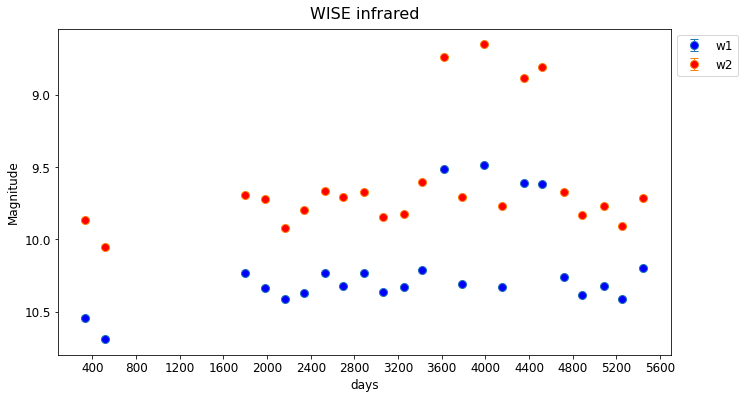

In [38]:
import matplotlib.pyplot as plt
from util import bin_the_light_curve
error_list = []
def neowise_do_it(path, ra, dec):

    ra_str = str(ra)[0:10]
    dec_str = str(dec)[0:10]
    allwise = ascii.read(path + '%s_%s_allwise.ipac'%(ra_str,dec_str), format='ipac')
    neowise = ascii.read(path + '%s_%s_neowise.ipac'%(ra_str,dec_str), format='ipac')

    # allwise, neowise = only_good_data_v1(allwise, neowise)
    t, mag, mag_err, filts = make_full_lightcurve_multibands(allwise, neowise)
    t_w1 = t[filts == 'w1'] - 55000
    t_w2 = t[filts == 'w2'] - 55000
    mag_w1 = mag[filts == 'w1']
    mag_w2 = mag[filts == 'w2']
    mag_err_w1 = mag_err[filts == 'w1']
    mag_err_w2 = mag_err[filts == 'w2']
    t_w1_bin, mag_w1_bin, mag_err_w1_bin = bin_the_light_curve(t_w1, mag_w1, mag_err_w1)
    t_w2_bin, mag_w2_bin, mag_err_w2_bin = bin_the_light_curve(t_w2, mag_w2, mag_err_w2)

    if len(t_w1_bin)<10:
        return
    
    median_mag_w1 = np.median(np.array(mag_w1_bin))
    sigma_mag_w1 = np.std(np.array(mag_w1_bin))
    median_mag_w2 = np.median(np.array(mag_w2_bin))
    sigma_mag_w2 = np.std(np.array(mag_w2_bin))
    t_w1_bin = [t_w1_bin[i] for i,mag in enumerate(mag_w1_bin) if abs(mag-median_mag_w1)<3*sigma_mag_w1]
    mag_err_w1_bin = [mag_err_w1_bin[i] for i,mag in enumerate(mag_w1_bin) if abs(mag-median_mag_w1)<3*sigma_mag_w1]
    mag_w1_bin = [mag_w1_bin[i] for i,mag in enumerate(mag_w1_bin) if abs(mag-median_mag_w1)<3*sigma_mag_w1] 
    t_w2_bin = [t_w2_bin[i] for i,mag in enumerate(mag_w2_bin) if abs(mag-median_mag_w2)<3*sigma_mag_w2]
    mag_err_w2_bin = [mag_err_w2_bin[i] for i,mag in enumerate(mag_w2_bin) if abs(mag-median_mag_w2)<3*sigma_mag_w2]
    mag_w2_bin = [mag_w2_bin[i] for i,mag in enumerate(mag_w2_bin) if abs(mag-median_mag_w2)<3*sigma_mag_w2]
    
    t1,m1,e1,t2,m2,e2 = t_w1_bin, mag_w1_bin, mag_err_w1_bin,t_w2_bin, mag_w2_bin, mag_err_w2_bin

    plot_fig(t1,m1,e1,t2,m2,e2,ra,dec)
    dict_list_w1 = []
    for i in range(len(t1)):
        dict_list_w1.append({'time_mjd':t1[i],'mag_w1':m1[i],'mag_err_w1':e1[i]})
    dict_list_w2 = []
    for i in range(len(t2)):
        dict_list_w2.append({'time_mjd':t2[i],'mag_w2':m2[i],'mag_err_w2':e2[i]})
    print(dict_list_w1)
    print(dict_list_w2)
    # with open('./special_lc_txt_test/%s_%s.txt'%(ra_str,dec_str),'w') as f:
    with open('./special_lc_txt_test/test.txt','w') as f:
        f.write('W1:\n'+str(dict_list_w1)+'\n')
        f.write('W2:\n'+str(dict_list_w2)+'\n')

path = './ipac/IR_extreme_luminious_'
for ra, dec in zip(ras, decs):
# for ra, dec in fix_list:

    # try:
        neowise_do_it(path, ra, dec)
    # except:
    #     print(ra)
    #     error_list.append((ra,dec))
    #     print('error')
    #     continue

In [18]:
import pandas as pd
import os
test_list = pd.read_csv('./special_test_sources.csv')
ras = test_list['ra']
decs = test_list['dec']
count = 0
error_list = []
for ra, dec in zip(ras, decs):
    ra_str = str(ra)[0:10]
    dec_str = str(dec)[0:10]
    if os.path.exists('./special_lc_txt_test/%s_%s.txt'%(ra_str,dec_str)) and os.path.exists('./special_feature_test/%f_%f.json'% (ra,dec)) and os.path.exists('./special_figs_test/%f_%f.png'%(ra,dec)):
        count += 1
    else:
        error_list.append((ra,dec))
print(error_list)
print(count)


[]
58


In [17]:
ra,dec = 245.14525, 24.12377777777778
print(ra,dec)
ra_str = str(ra)[0:10]
dec_str = str(dec)[0:10]
print('./special_lc_txt_test/%s_%s.txt'%(ra_str,dec_str))
print('./special_feature_test/%f_%f.json'% (ra,dec))
print('./special_figs_test/%f_%f.png'%(ra,dec))

os.path.exists('./special_lc_txt_test/%s_%s.txt'%(ra_str,dec_str)) and os.path.exists('./special_feature_test/%f_%f.json'% (ra,dec)) and os.path.exists('./special_figs_test/%f_%f.png'%(ra,dec))

245.14525 24.12377777777778
./special_lc_txt_test/245.14525_24.1237777.txt
./special_feature_test/245.145250_24.123778.json
./special_figs_test/245.145250_24.123778.png


True

In [28]:
fix_list = [(288.798148, 10.945807), (308.107416, 40.9577500), (314.262374, 14.2044055), (245.145249, 24.1237777)]